## Project Overview

This project explores hotel booking data to understand booking behavior, data quality, and early business patterns across City and Resort hotels.

The analysis begins with data inspection and cleaning, including missing values, duplicates, and date formatting. It then moves beyond basic summary statistics to explore booking status, cancellations, customer segments, seasonal demand, and average daily rates.

The goal is not only to prepare a clean dataset, but also to turn the first exploration into meaningful business observations that could support hotel operations and revenue-related decisions.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\anarrasulzada\Desktop\hotel_bookings.csv")

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (119390, 32)


In [6]:
print("Column names:")
print(df.columns.tolist())

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [7]:
missing_values = df.isnull().sum()  # checking missing values 

missing_values[missing_values > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [8]:
missing_percent = (df.isnull().sum() / len(df)) * 100   # calculating missing value percentages

missing_percent[missing_percent > 0].round(2)

children     0.00
country      0.41
agent       13.69
company     94.31
dtype: float64

In [9]:
duplicate_count = df.duplicated().sum()    # the sum of duplicate rows

print("Duplicate rows:", duplicate_count)

Duplicate rows: 31994


### Converting reservation dates to datetime

In [10]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

df['reservation_status_date'].dtype

dtype('<M8[us]')

### Reviewing missing-value patterns before cleaning

In [11]:
missing_summary = pd.DataFrame({'missing_count': df.isnull().sum(), 
                                'missing_percent': (df.isnull().sum() / len(df) * 100).round(2)})

missing_summary = missing_summary[missing_summary['missing_count'] > 0]

missing_summary

# this cell calculates both the number and percentage of missing values in each column. 
# the purpose is to understand the scale of missing data before deciding how to clean it. 
# a column with only a few missing values may be handled differently from a column where most of the data is missing.

,missing_count,missing_percent
children,4,0.00
country,488,0.41
agent,16340,13.69
company,112593,94.31


### Handling missing values based on column

In [12]:
df['children'] = df['children'].fillna(0)

df['country'] = df['country'].fillna('Unknown')

df['agent'] = df['agent'].fillna(0)

df['company'] = df['company'].fillna(0)

In [13]:
df.isnull().sum().sum()

np.int64(0)

In [14]:
# np.int64(0)  shows that there is no missing value in the dataset.

### Verifying data types

In [15]:
df[['reservation_status_date', 'children', 'agent', 'company']].dtypes   # after cleaning 

reservation_status_date    datetime64[us]
children                          float64
agent                             float64
company                           float64
dtype: object

### Investigating duplicate records

In [16]:
duplicate_count = df.duplicated().sum()
duplicate_percent = duplicate_count / len(df) * 100

print("Duplicate rows:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percent:.2f}%")

Duplicate rows: 31994
Duplicate percentage: 26.80%


## Understanding the Overall Booking Profile

After cleaning the dataset, the next step is to build a general picture of the booking activity.

In [17]:
df.describe().round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.0,119390.00,...,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,...,0.09,0.14,0.22,74.83,10.78,2.32,101.83,0.06,0.57,2016-07-30 00:24:47.883407
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,-6.38,0.00,0.00,2014-10-17 00:00:00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,...,0.00,0.00,0.00,7.00,0.00,0.00,69.29,0.00,0.00,2016-02-01 00:00:00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,...,0.00,0.00,0.00,9.00,0.00,0.00,94.58,0.00,0.00,2016-08-07 00:00:00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,...,0.00,0.00,0.00,152.00,0.00,0.00,126.00,0.00,1.00,2017-02-08 00:00:00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,...,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00,2017-09-14 00:00:00
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,...,0.84,1.50,0.65,107.14,53.94,17.59,50.54,0.25,0.79,NaN


In [19]:
booking_metrics = df[
    [
        'lead_time',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'adults',
        'children',
        'adr'
    ]
]

booking_metrics.describe().round(2)    # the variables most relevant to booking behavior, including lead time, 
                                      #stay duration, guest composition and average daily rate.

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,adr
count,119390.00,119390.00,119390.00,119390.00,119390.0,119390.00
mean,104.01,0.93,2.50,1.86,0.1,101.83
std,106.86,1.00,1.91,0.58,0.4,50.54
min,0.00,0.00,0.00,0.00,0.0,-6.38
25%,18.00,0.00,1.00,2.00,0.0,69.29
50%,69.00,1.00,2.00,2.00,0.0,94.58
75%,160.00,2.00,3.00,2.00,0.0,126.00
max,737.00,19.00,50.00,55.00,10.0,5400.00


### Total stay and guest measures

In [22]:
df['total_nights'] = (df['stays_in_weekend_nights'] + df['stays_in_week_nights'])

df['total_guests'] = (df['adults'] + df['children'] + df['babies'])

In [24]:
df[['total_nights', 'total_guests', 'lead_time', 'adr']].describe().round(2)   

# summarizes the newly created stay and guest measures together with lead time and room rate, 
# providing a more intuitive view of a typical hotel reservation.

,total_nights,total_guests,lead_time,adr
count,119390.00,119390.00,119390.00,119390.00
mean,3.43,1.97,104.01,101.83
std,2.56,0.72,106.86,50.54
min,0.00,0.00,0.00,-6.38
25%,2.00,2.00,18.00,69.29
50%,3.00,2.00,69.00,94.58
75%,4.00,2.00,160.00,126.00
max,69.00,55.00,737.00,5400.00


### Exploring the distribution of hotel types

In [25]:
df['hotel'].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [27]:
# to compare the number of reservations recorded for City Hotel and Resort Hotel.

hotel_distribution = df['hotel'].value_counts(normalize=True) * 100  

hotel_distribution.round(2)

hotel
City Hotel      66.45
Resort Hotel    33.55
Name: proportion, dtype: float64

### Exploring reservation outcomes

In [28]:
df['reservation_status'].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [30]:
# examining the final status of reservations and shows how frequently bookings were completed, canceled or recorded as no-shows.

reservation_status_percent = (df['reservation_status'].value_counts(normalize=True).mul(100).round(2))

reservation_status_percent

reservation_status
Check-Out    62.96
Canceled     36.03
No-Show       1.01
Name: proportion, dtype: float64

### Exploring booking activity across years

In [31]:
df['arrival_date_year'].value_counts().sort_index()

arrival_date_year
2015    21996
2016    56707
2017    40687
Name: count, dtype: int64

In [32]:
year_distribution = (df['arrival_date_year'].value_counts(normalize=True).sort_index().mul(100).round(2))

year_distribution

arrival_date_year
2015    18.42
2016    47.50
2017    34.08
Name: proportion, dtype: float64

### Exploring the main market segments

Identifing which market segments generate the largest share of hotel reservations.

In [33]:
df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [34]:
market_segment_percent = (df['market_segment'].value_counts(normalize=True).mul(100).round(2))

market_segment_percent

market_segment
Online TA        47.30
Offline TA/TO    20.29
Groups           16.59
Direct           10.56
Corporate         4.44
Complementary     0.62
Aviation          0.20
Undefined         0.00
Name: proportion, dtype: float64

### Building a market segment performance profile

In [56]:
segment_profile = (df.groupby('market_segment').agg(
        total_bookings=('hotel', 'size'),
        cancellation_rate=('is_canceled', 'mean'),
        average_adr=('adr', 'mean')
    )
)

segment_profile['cancellation_rate'] = (segment_profile['cancellation_rate'] * 100)

segment_profile.round(2).sort_values('total_bookings',ascending=False)

# In this cell I compared market segments by booking volume, cancellation rate and average daily rate to identify which channels bring 
 # the most reservations and how stable or valuable those bookings are.

,total_bookings,cancellation_rate,average_adr
market_segment,,,
Online TA,56477,36.72,117.20
Offline TA/TO,24219,34.32,87.35
Groups,19811,61.06,79.48
Direct,12606,15.34,115.45
Corporate,5295,18.73,69.36
Complementary,743,13.06,2.89
Aviation,237,21.94,100.14
Undefined,2,100.00,15.00


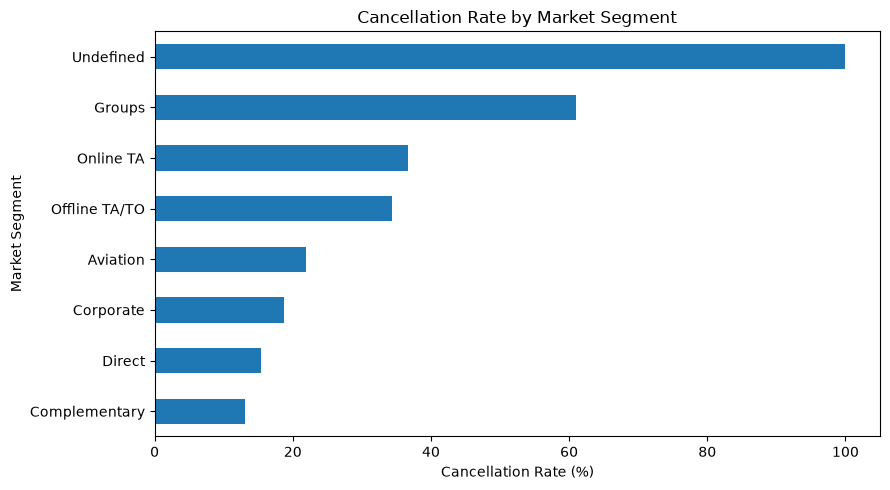

In [57]:
segment_cancellation = (segment_profile['cancellation_rate'].sort_values())

segment_cancellation.plot(kind='barh',figsize=(9, 5))

plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Market Segment')
plt.tight_layout()
plt.show()

### Exploring customer types

In [35]:
df['customer_type'].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [36]:
customer_type_percent = (
    df['customer_type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

customer_type_percent

customer_type
Transient          75.06
Transient-Party    21.04
Contract            3.41
Group               0.48
Name: proportion, dtype: float64

### Building a booking snapshot

# This cell summarizes several key indicators into a compact booking snapshot, including total reservations, cancellation rate, average lead time, average stay length and average daily rate.

In [41]:
total_bookings = len(df)

cancellation_rate = (df['is_canceled'].mean() * 100)

average_lead_time = df['lead_time'].mean()

average_stay = df['total_nights'].mean()

average_adr = df['adr'].mean()

print(f"Total bookings: {total_bookings:,}")
print(f"Cancellation rate: {cancellation_rate:.2f}%")
print(f"Average lead time: {average_lead_time:.1f} days")
print(f"Average stay length: {average_stay:.2f} nights")
print(f"Average daily rate: {average_adr:.2f}")

Total bookings: 119,390
Cancellation rate: 37.04%
Average lead time: 104.0 days
Average stay length: 3.43 nights
Average daily rate: 101.83


### Exploring Cancellation Behavior

#### Cancellations can directly affect hotel occupancy planning and expected revenue. This section explores whether cancellation behavior differs across hotel types, booking channels and reservation lead times.

In [38]:
cancellation_by_hotel = (
    df.groupby('hotel')['is_canceled']
    .mean()
    .mul(100)
    .round(2)
)

cancellation_by_hotel        # comparing cancellation rates by hotel type

hotel
City Hotel      41.73
Resort Hotel    27.76
Name: is_canceled, dtype: float64

In [42]:
hotel_cancellation_summary = (
    df.groupby('hotel').agg(
        total_bookings=('is_canceled', 'size'),
        canceled_bookings=('is_canceled', 'sum'),
        cancellation_rate=('is_canceled', 'mean')
    )
)

hotel_cancellation_summary['cancellation_rate'] = (hotel_cancellation_summary['cancellation_rate'] * 100).round(2)

hotel_cancellation_summary         # combines total booking volume, canceled bookings and cancellation rate for each hotel type, 
                                   # allowing both scale and cancellation behavior to be compared together.

,total_bookings,canceled_bookings,cancellation_rate
hotel,,,
City Hotel,79330,33102,41.73
Resort Hotel,40060,11122,27.76


### Comparing cancellation rates across market segments

In [44]:
segment_cancellation = (df.groupby('market_segment')['is_canceled'].agg(['count', 'sum', 'mean']))

segment_cancellation.columns = ['total_bookings','canceled_bookings','cancellation_rate']

segment_cancellation['cancellation_rate'] = (segment_cancellation['cancellation_rate'] * 100).round(2)

segment_cancellation.sort_values('cancellation_rate', ascending=False)

,total_bookings,canceled_bookings,cancellation_rate
market_segment,,,
Undefined,2,2,100.00
Groups,19811,12097,61.06
Online TA,56477,20739,36.72
Offline TA/TO,24219,8311,34.32
Aviation,237,52,21.94
Corporate,5295,992,18.73
Direct,12606,1934,15.34
Complementary,743,97,13.06


### Filtering out very small market segments

The comparison on market segments with a meaningful number of bookings, reducing the risk of drawing conclusions from very small groups.

In [45]:
major_segments = segment_cancellation[
    segment_cancellation['total_bookings'] >= 100
]

major_segments.sort_values(
    'cancellation_rate',
    ascending=False
)

,total_bookings,canceled_bookings,cancellation_rate
market_segment,,,
Groups,19811,12097,61.06
Online TA,56477,20739,36.72
Offline TA/TO,24219,8311,34.32
Aviation,237,52,21.94
Corporate,5295,992,18.73
Direct,12606,1934,15.34
Complementary,743,97,13.06


### Lead time və cancellation 

Grouping bookings by lead time

Grouping bookings into practical lead-time ranges so that cancellation behavior can be compared between last-minute and early reservations.

In [46]:
df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, float('inf')],
    labels=[
        '0-7 days',
        '8-30 days',
        '31-90 days',
        '91-180 days',
        '181-365 days',
        '365+ days'
    ]
)

df['lead_time_group'].value_counts().sort_index()

lead_time_group
0-7 days        19746
8-30 days       18960
31-90 days      29553
91-180 days     26439
181-365 days    21544
365+ days        3148
Name: count, dtype: int64

### Examining cancellation rates by lead-time group

In [48]:
lead_time_cancellation = (df.groupby('lead_time_group', observed=True)['is_canceled'].mean().mul(100).round(2))

lead_time_cancellation

# customers booking far in advance may have a higher likelihood of canceling compared with last-minute guests.

lead_time_group
0-7 days         9.63
8-30 days       27.86
31-90 days      37.70
91-180 days     44.71
181-365 days    55.45
365+ days       67.66
Name: is_canceled, dtype: float64

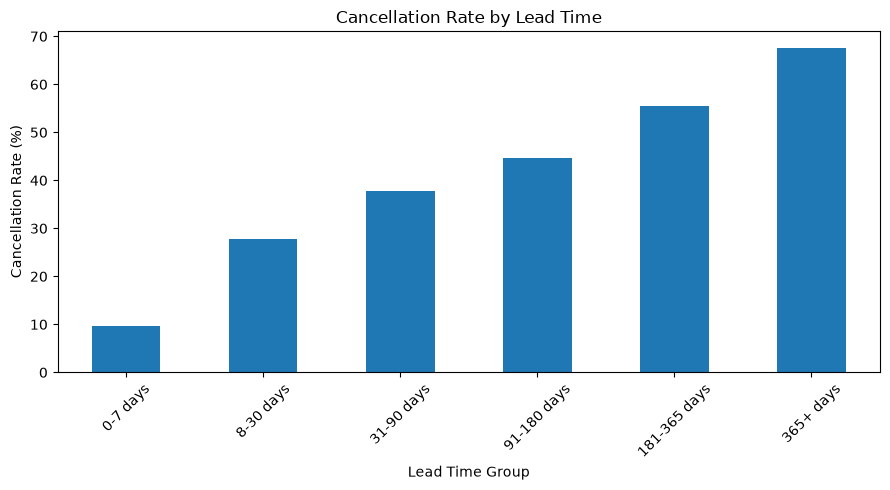

In [49]:
lead_time_cancellation.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time Group')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Comparing cancellation rates by customer type

In [51]:
# In this part I compared cancellation behavior across customer types to determine whether certain customer groups are more likely to cancel their reservations.

customer_cancellation = (df.groupby('customer_type')['is_canceled'].agg(total_bookings='count',cancellation_rate='mean'))

customer_cancellation['cancellation_rate'] = (customer_cancellation['cancellation_rate'] * 100).round(2)

customer_cancellation.sort_values('cancellation_rate',ascending=False)

,total_bookings,cancellation_rate
customer_type,,
Transient,89613,40.75
Contract,4076,30.96
Transient-Party,25124,25.43
Group,577,10.23


### Comparing lead-time cancellation patterns across hotel types

In [52]:
hotel_lead_cancellation = (df.groupby(['lead_time_group', 'hotel'], observed=True)['is_canceled'].mean().mul(100).round(2).unstack())

hotel_lead_cancellation

hotel,City Hotel,Resort Hotel
lead_time_group,,
0-7 days,12.20,6.52
8-30 days,30.91,21.90
31-90 days,39.91,32.45
91-180 days,47.99,37.43
181-365 days,62.72,41.27
365+ days,71.12,46.62


### Visualizing hotel-specific cancellation patterns

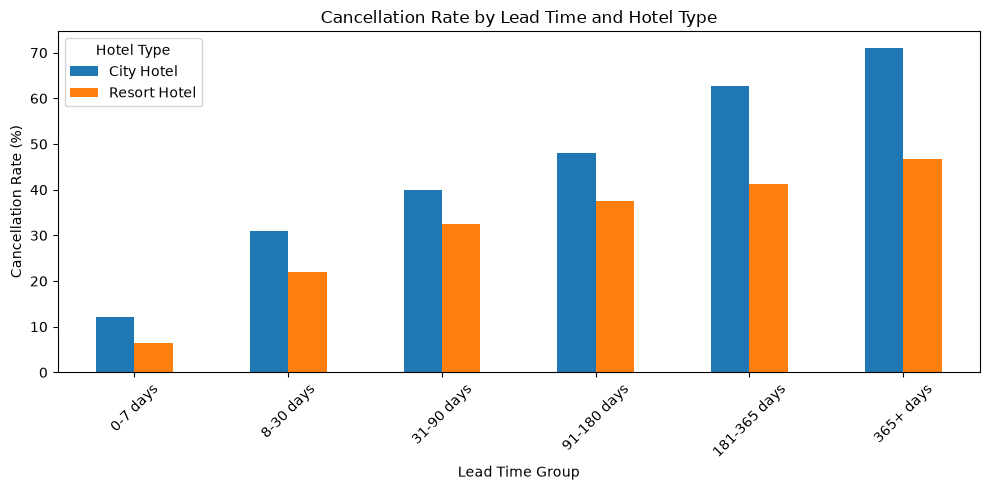

In [53]:
hotel_lead_cancellation.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Cancellation Rate by Lead Time and Hotel Type')
plt.xlabel('Lead Time Group')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

### Overall reservation outcome

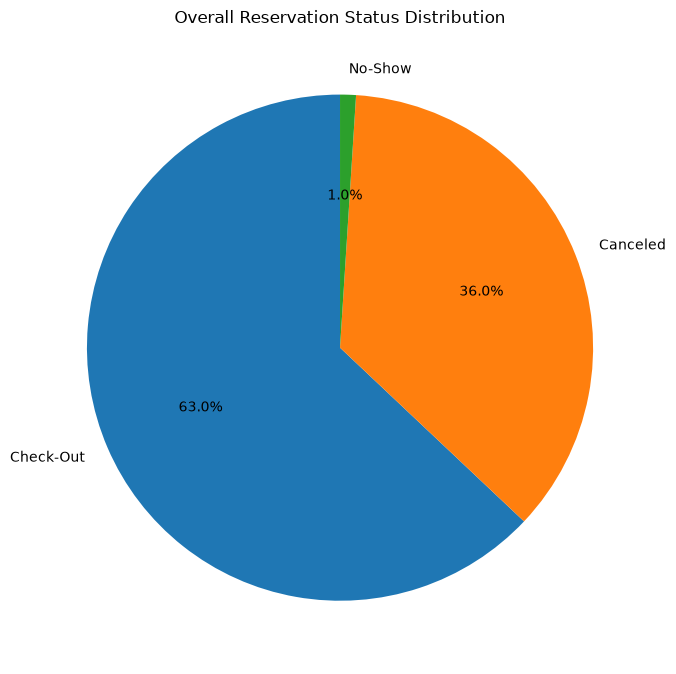

In [58]:
status_counts = df['reservation_status'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Overall Reservation Status Distribution')
plt.tight_layout()
plt.show()

### Comparing ADR distribution between hotel types

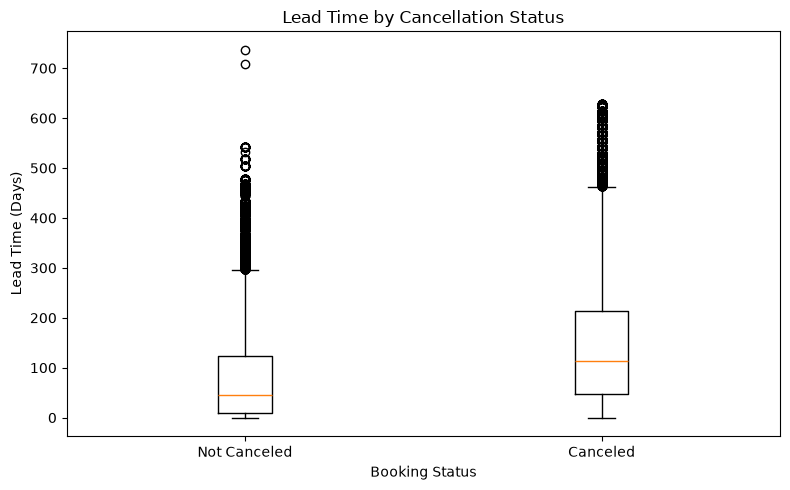

In [61]:
not_canceled = df[df['is_canceled'] == 0]['lead_time']
canceled = df[df['is_canceled'] == 1]['lead_time']

plt.figure(figsize=(8, 5))

plt.boxplot(
    [not_canceled, canceled],
    tick_labels=['Not Canceled', 'Canceled'],
    showfliers=True
)

plt.title('Lead Time by Cancellation Status')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time (Days)')
plt.tight_layout()
plt.show()